## 1. Импорт библиотек

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    f1_score, precision_score, recall_score
)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120})
COLORS = ['#5b7fc7', '#4caf7d', '#e08040']
print('Все библиотеки загружены')

Все библиотеки загружены


## 2. Загрузка данных

In [13]:
df = pd.read_csv('finances.csv', encoding='utf-8-sig')
print(f'Размер: {df.shape[0]:,} строк, {df.shape[1]} столбцов')
print(f'Столбцы: {list(df.columns)}')
print(f'\nПропуски:')
print(df.isnull().sum())
print(f'\nКлассы:')
vc = df['Type'].value_counts()
for k, v in vc.items():
    print(f'  {k}: {v:,} ({v/len(df)*100:.1f}%)')
df.head()

Размер: 8,019 строк, 5 столбцов
Столбцы: ['Date', 'Type', 'Category', 'Amount', 'Comment']

Пропуски:
Date        0
Type        0
Category    0
Amount      0
Comment     0
dtype: int64

Классы:
  Расход: 7,392 (92.2%)
  Доход: 627 (7.8%)


,Date,Type,Category,Amount,Comment
0,2018-01-01,Расход,Транспорт,1819.76,Автобус
1,2018-01-02,Доход,Наличка,15802.96,Сдача
2,2018-01-04,Расход,Продукты,570.90,Бристоль
3,2018-01-04,Расход,Продукты,4729.89,Лента
4,2018-01-04,Расход,Транспорт,1336.33,Такси


## 3.Признаки

In [14]:
df = df.copy()
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce').fillna(0)
df['Date']   = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date', 'Type'])

# Временные признаки
df['month']          = df['Date'].dt.month
df['day']            = df['Date'].dt.day
df['weekday']        = df['Date'].dt.weekday
df['is_weekend']     = (df['weekday'] >= 5).astype(int)
df['quarter']        = df['Date'].dt.quarter
df['year']           = df['Date'].dt.year
df['is_month_start'] = (df['day'] <= 5).astype(int)
df['is_month_end']   = (df['day'] >= 25).astype(int)

# Признаки суммы
df['log_amount']  = np.log1p(df['Amount'])
df['sqrt_amount'] = np.sqrt(df['Amount'])

# Кодирование категории
le = LabelEncoder()
df['category_enc'] = le.fit_transform(df['Category'].fillna('Unknown'))

# Целевая переменная
df['target'] = (df['Type'].str.strip() == 'Расход').astype(int)

FEATURES = ['Amount','log_amount','sqrt_amount','month','day','weekday',
            'is_weekend','quarter','year','is_month_start','is_month_end','category_enc']
FEAT_NAMES = ['Сумма','Log(Сумма)','√Сумма','Месяц','День','День недели',
              'Выходной','Квартал','Год','Нач.месяца','Кон.месяца','Категория']

print(f'Признаков: {len(FEATURES)}')
print(f'Расходов: {(df.target==1).sum():,} | Доходов: {(df.target==0).sum():,}')

Признаков: 12
Расходов: 7,392 | Доходов: 627


## 4. Разделение данных

In [15]:
X = df[FEATURES].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Доля Расход — Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}')

Train: 6,415  |  Test: 1,604
Доля Расход — Train: 92.17%  |  Test: 92.21%


## 5. Обучение моделей

In [16]:
probas    = {}
estimators = {}

# 1. Логистическая регрессия
print('Обучение: Логистическая регрессия...')
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_sc, y_train)
probas['Логист. регрессия']    = lr.predict_proba(X_test_sc)[:, 1]
estimators['Логист. регрессия'] = (lr, X_train_sc, X_test_sc)
print(f'  ROC-AUC = {roc_auc_score(y_test, probas["Логист. регрессия"]):.4f}')

# 2. Random Forest
print('Обучение: Random Forest...')
rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                             min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
probas['Random Forest']    = rf.predict_proba(X_test)[:, 1]
estimators['Random Forest'] = (rf, X_train, X_test)
print(f'  ROC-AUC = {roc_auc_score(y_test, probas["Random Forest"]):.4f}')

# 3. Gradient Boosting
print('Обучение: Gradient Boosting...')
gb = GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                 learning_rate=0.05, subsample=0.8, random_state=42)
gb.fit(X_train, y_train)
probas['Gradient Boosting']    = gb.predict_proba(X_test)[:, 1]
estimators['Gradient Boosting'] = (gb, X_train, X_test)
print(f'  ROC-AUC = {roc_auc_score(y_test, probas["Gradient Boosting"]):.4f}')

print('\nВсе модели обучены!')

Обучение: Логистическая регрессия...
  ROC-AUC = 0.8587
Обучение: Random Forest...
  ROC-AUC = 0.9595
Обучение: Gradient Boosting...
  ROC-AUC = 0.9574

Все модели обучены!


## 6. График 1 — ROC-AUC кривые

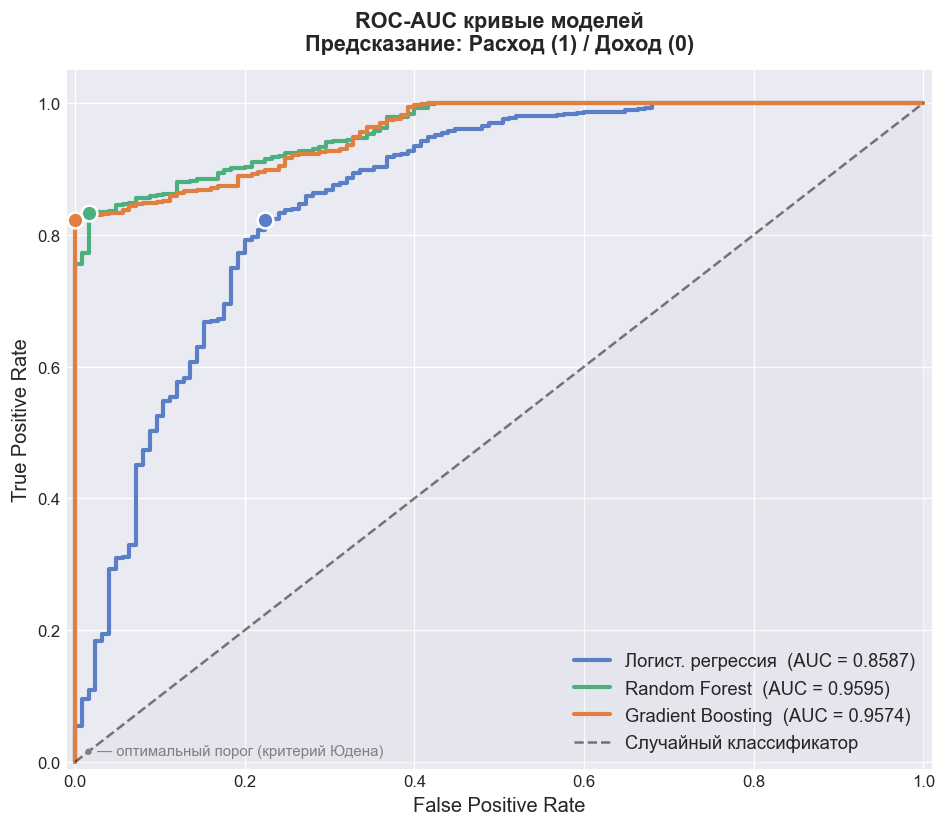

Сохранено: roc_auc.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 7))

for (name, proba), color in zip(probas.items(), COLORS):
    fpr, tpr, thresholds = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f'{name}  (AUC = {roc_auc:.4f})')
    # Оптимальный порог по критерию Юдена
    best_idx = np.argmax(tpr - fpr)
    ax.scatter(fpr[best_idx], tpr[best_idx], s=90,
               color=color, zorder=5, edgecolors='white', lw=1.5)

ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Случайный классификатор')
ax.fill_between([0,1],[0,1], alpha=0.04, color='gray')
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC кривые моделей\n'
             'Предсказание: Расход (1) / Доход (0)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=11)
ax.text(0.02, 0.02, '● — оптимальный порог (критерий Юдена)',
        fontsize=9, color='gray', transform=ax.transAxes)
plt.tight_layout()
plt.savefig('roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: roc_auc.png')

## 7. График 2 — Матрицы ошибок

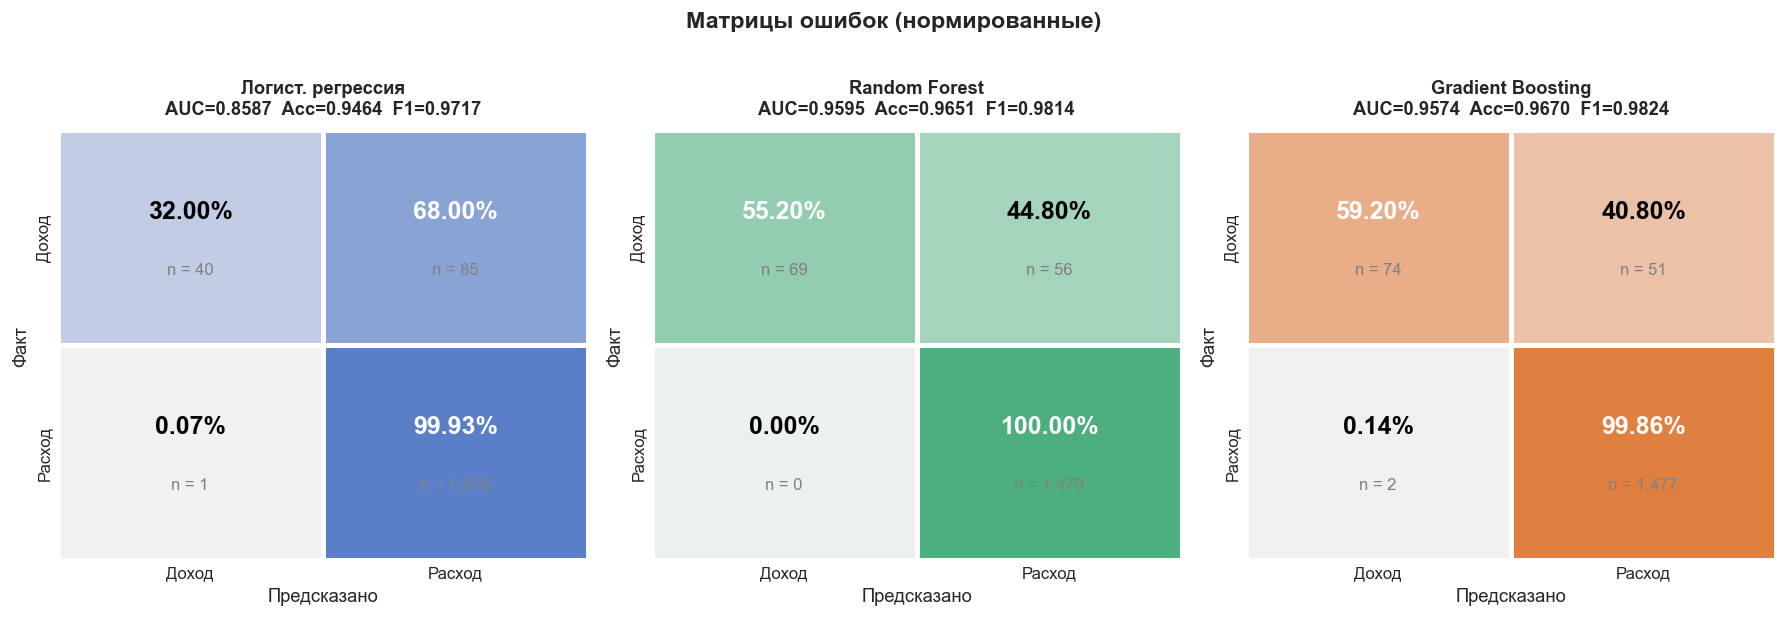

Сохранено: confusion_matrices.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, proba), color in zip(axes, probas.items(), COLORS):
    yp  = (proba >= 0.5).astype(int)
    cm  = confusion_matrix(y_test, yp)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cmn, ax=ax, cmap=sns.light_palette(color, as_cmap=True),
                annot=False, linewidths=2, linecolor='white',
                xticklabels=['Доход','Расход'],
                yticklabels=['Доход','Расход'],
                vmin=0, vmax=1, cbar=False)

    for i in range(2):
        for j in range(2):
            txt_color = 'white' if cmn[i,j] > 0.55 else 'black'
            ax.text(j+0.5, i+0.38, f'{cmn[i,j]:.2%}',
                    ha='center', va='center', fontsize=15,
                    fontweight='bold', color=txt_color)
            ax.text(j+0.5, i+0.65, f'n = {cm[i,j]:,}',
                    ha='center', va='center', fontsize=10, color='gray')

    roc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, yp)
    f1  = f1_score(y_test, yp)
    ax.set_title(f'{name}\nAUC={roc:.4f}  Acc={acc:.4f}  F1={f1:.4f}',
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Предсказано', fontsize=11)
    ax.set_ylabel('Факт', fontsize=11)

plt.suptitle('Матрицы ошибок (нормированные)', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: confusion_matrices.png')

## 8. Итоговое сравнение

In [19]:
rows = []
for name, proba in probas.items():
    yp = (proba >= 0.5).astype(int)
    rows.append({
        'Модель':    name,
        'ROC-AUC':   round(roc_auc_score(y_test, proba), 4),
        'Accuracy':  round(accuracy_score(y_test, yp),   4),
        'F1':        round(f1_score(y_test, yp),         4),
        'Precision': round(precision_score(y_test, yp),  4),
        'Recall':    round(recall_score(y_test, yp),     4),
    })

res = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('=== Сравнение моделей ===')
display(res)

best = res.iloc[0]
print(f'\nЛучшая модель: {best["Модель"]}  (ROC-AUC = {best["ROC-AUC"]})')
print(f'\nДетальный отчёт — {best["Модель"]}:')
print(classification_report(
    y_test, (probas[best['Модель']] >= 0.5).astype(int),
    target_names=['Доход', 'Расход']
))

=== Сравнение моделей ===


,Модель,ROC-AUC,Accuracy,F1,Precision,Recall
0,Random Forest,0.9595,0.9651,0.9814,0.9635,1.0000
1,Gradient Boosting,0.9574,0.9670,0.9824,0.9666,0.9986
2,Логист. регрессия,0.8587,0.9464,0.9717,0.9456,0.9993



Лучшая модель: Random Forest  (ROC-AUC = 0.9595)

Детальный отчёт — Random Forest:
              precision    recall  f1-score   support

       Доход       1.00      0.55      0.71       125
      Расход       0.96      1.00      0.98      1479

    accuracy                           0.97      1604
   macro avg       0.98      0.78      0.85      1604
weighted avg       0.97      0.97      0.96      1604

